In [3]:
#Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [4]:
#Loading dataset and assigning column names
cols = ['target', 'ids', 'date', 'flag', 'user', 'text']
df = pd.read_csv(r'D:\Projects\DataScience\Sentiment Analysis\data.csv', encoding='latin-1', names=cols)

df.head()

,target,ids,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [ ]:
df.info()
df['target'].value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 1600000 entries, 0 to 1599999
Data columns (total 6 columns):
 #   Column  Non-Null Count    Dtype
---  ------  --------------    -----
 0   target  1600000 non-null  int64
 1   ids     1600000 non-null  int64
 2   date    1600000 non-null  str  
 3   flag    1600000 non-null  str  
 4   user    1600000 non-null  str  
 5   text    1600000 non-null  str  
dtypes: int64(2), str(4)
memory usage: 73.2 MB


target
0    800000
4    800000
Name: count, dtype: int64

In [7]:
df['target'] = df['target'].replace(4, 1)
df['target'].value_counts()

target
0    800000
1    800000
Name: count, dtype: int64

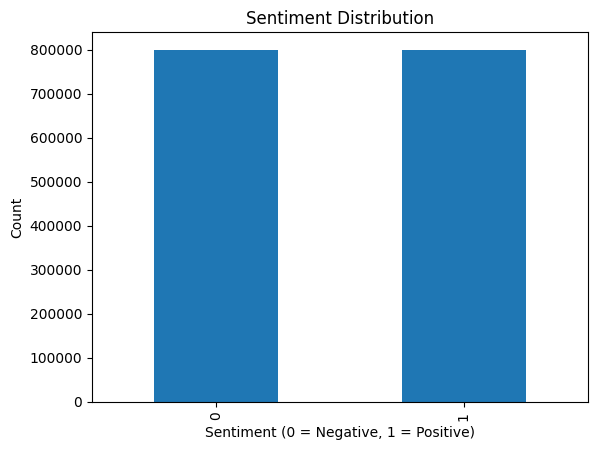

In [8]:
plt.figure()
df['target'].value_counts().plot(kind='bar')
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment (0 = Negative, 1 = Positive)')
plt.ylabel('Count')
plt.show()

In [9]:
#Text Cleaning
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)    #removing URLs
    text = re.sub(r'@\w+', '', text)     #removing mentions
    text = re.sub(r'[^a-zA-Z\s]', '', text)     #removing special character
    return text

df['clean_text'] = df['text'].apply(clean_text)

In [11]:
#Old text vs Cleaned text
df[['text', 'clean_text']].head()

,text,clean_text
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",awww thats a bummer you shoulda got david ...
1,is upset that he can't update his Facebook by ...,is upset that he cant update his facebook by t...
2,@Kenichan I dived many times for the ball. Man...,i dived many times for the ball managed to sa...
3,my whole body feels itchy and like its on fire,my whole body feels itchy and like its on fire
4,"@nationwideclass no, it's not behaving at all....",no its not behaving at all im mad why am i he...


In [12]:
X = df['clean_text']
y = df['target']

X_train, X_text, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)   

In [13]:
#Text Vectorization (TF-IDF)
vectorizer = TfidfVectorizer(max_features=5000)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_text)

In [15]:
model = LogisticRegression()
model.fit(X_train_vec, y_train)

y_pred = model.predict(X_test_vec)

In [16]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.790290625
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.78      0.79    159494
           1       0.78      0.80      0.79    160506

    accuracy                           0.79    320000
   macro avg       0.79      0.79      0.79    320000
weighted avg       0.79      0.79      0.79    320000



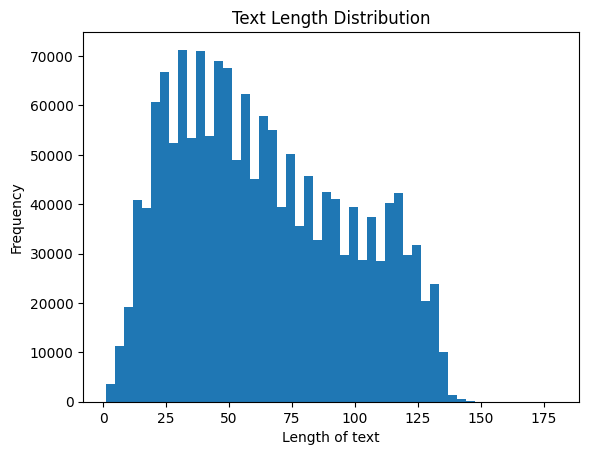

In [17]:
df['length'] = df['clean_text'].apply(len)

plt.figure()
plt.hist(df['length'], bins=50)
plt.title('Text Length Distribution')
plt.xlabel('Length of text')
plt.ylabel('Frequency')
plt.show()

In [22]:
feature_names = vectorizer.get_feature_names_out()
coefficients = model.coef_[0]

top_positive = np.argsort(coefficients)[-10:]
top_negative = np.argsort(coefficients)[:10]

print("Top Positive Words:")
print([feature_names[i] for i in top_positive])

print("Top Negative Words:")
print([feature_names[i] for i in top_negative])

Top Positive Words:
['pleasure', 'glad', 'excited', 'congratulations', 'proud', 'thanks', 'wait', 'smiling', 'smile', 'worries']
Top Negative Words:
['sad', 'miss', 'sadly', 'rip', 'bummed', 'gutted', 'unfortunately', 'sucks', 'disappointed', 'died']


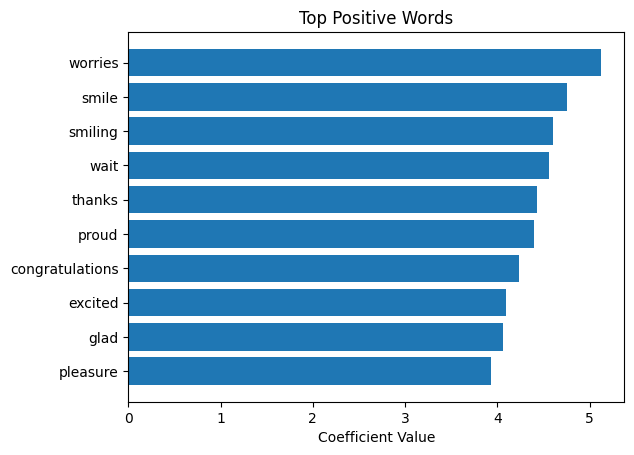

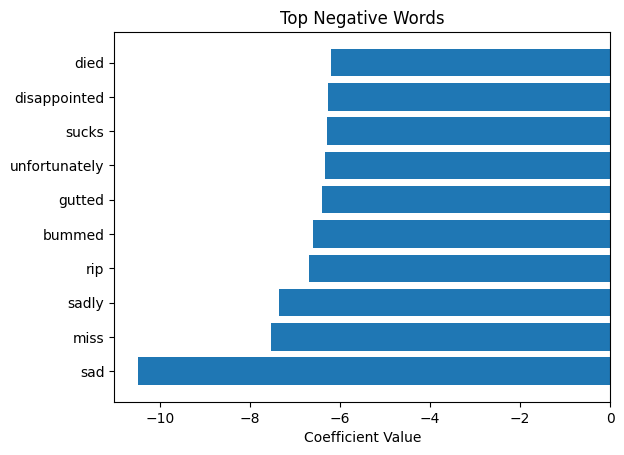

In [23]:
top_pos_words = [feature_names[i] for i in top_positive]
top_neg_words = [feature_names[i] for i in top_negative]

plt.figure()
plt.barh(top_pos_words, coefficients[top_positive])
plt.title("Top Positive Words")
plt.xlabel("Coefficient Value")
plt.show()

plt.figure()
plt.barh(top_neg_words, coefficients[top_negative])
plt.title("Top Negative Words")
plt.xlabel("Coefficient Value")
plt.show()

In [29]:
def predict_sentiment(text):
    cleaned = clean_text(text)
    vectorized = vectorizer.transform([cleaned])
    prediction = model.predict(vectorized)[0]

    if prediction == 1:
        return "Positive"
    else:
        return "Negative"
    
user_text = input("Enter a sentence: ")
result = predict_sentiment(user_text)
print("\nInput:", user_text)
print("Sentiment:", result)


Input: This as the most beautiful experience I had.
Sentiment: Positive
